# 04 - Analyse Éducation

Analyse des disparités territoriales en matière d'éducation primaire : effectifs, ratio élèves/enseignant, éducation prioritaire.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import DATA_PROCESSED, OUTPUTS

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 10

In [2]:
eleves = pd.read_parquet(DATA_PROCESSED / "effectifs_eleves.parquet")
pers = pd.read_parquet(DATA_PROCESSED / "personnels_1er_degre.parquet")
ep = pd.read_parquet(DATA_PROCESSED / "education_prioritaire.parquet")
edu_dep = pd.read_parquet(DATA_PROCESSED / "education_par_departement.parquet")

print(f"Écoles: {eleves.shape}")
print(f"Personnels: {pers.shape}")
print(f"Éducation prioritaire: {ep.shape}")
print(f"Éducation/dép: {edu_dep.shape}")

Écoles: (809225, 12)
Personnels: (47507, 11)
Éducation prioritaire: (8501, 12)
Éducation/dép: (101, 10)


## 4.1 État des lieux de l'éducation primaire

In [3]:
total_ecoles = len(eleves)
nb_rep = (eleves["REP"] == "REP").sum()
nb_repp = (eleves["REP+"] == "REP+").sum()
nb_epp = nb_rep + nb_repp
total_eleves = eleves["nb_eleves"].sum()

print(f"Total écoles: {total_ecoles:,}")
print(f"Total élèves: {total_eleves:,.0f}")
print(f"Écoles REP: {nb_rep:,} ({nb_rep/total_ecoles*100:.1f}%)")
print(f"Écoles REP+: {nb_repp:,} ({nb_repp/total_ecoles*100:.1f}%)")
print(f"Écoles en éducation prioritaire: {nb_epp:,} ({nb_epp/total_ecoles*100:.1f}%)")

Total écoles: 809,225
Total élèves: 105,988,320
Écoles REP: 0 (0.0%)
Écoles REP+: 0 (0.0%)
Écoles en éducation prioritaire: 0 (0.0%)


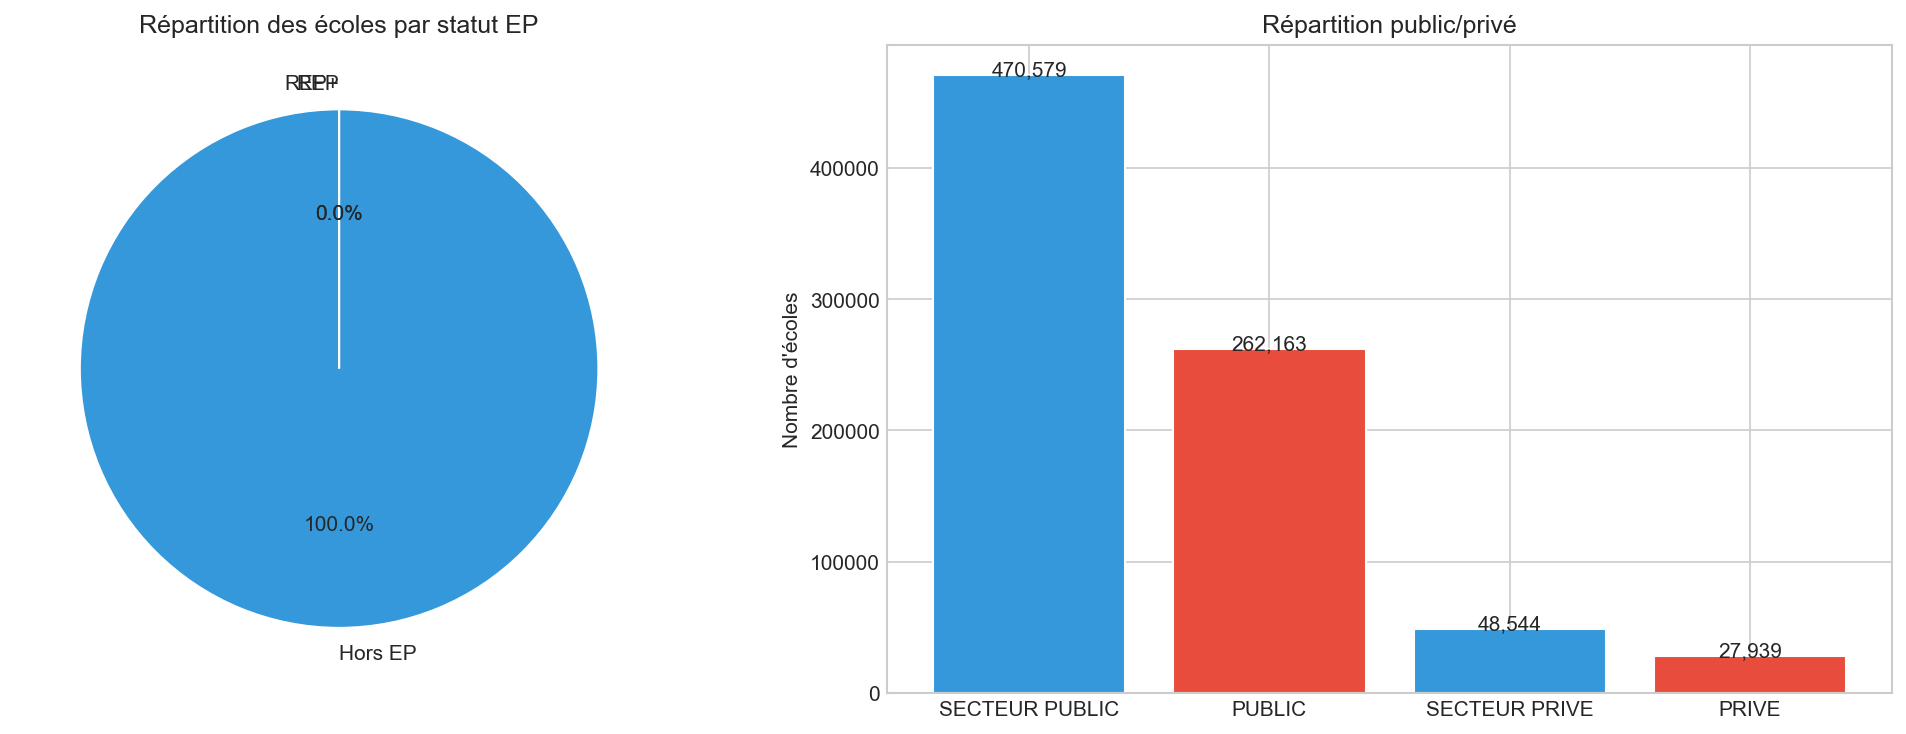

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_rep = ["Hors EP", "REP", "REP+"]
values_rep = [total_ecoles - nb_epp, nb_rep, nb_repp]
colors_rep = ["#3498db", "#f39c12", "#e74c3c"]
axes[0].pie(values_rep, labels=labels_rep, colors=colors_rep, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 10})
axes[0].set_title("Répartition des écoles par statut EP")

secteurs = eleves["Secteur"].value_counts()
axes[1].bar(secteurs.index, secteurs.values, color=["#3498db", "#e74c3c"], edgecolor="white")
axes[1].set_ylabel("Nombre d'écoles")
axes[1].set_title("Répartition public/privé")
for i, (label, val) in enumerate(zip(secteurs.index, secteurs.values)):
    axes[1].text(i, val + 100, f"{val:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUTS / "06_repartition_ecoles.png", bbox_inches="tight")
plt.show()

## 4.2 Ratio élèves / enseignant par département

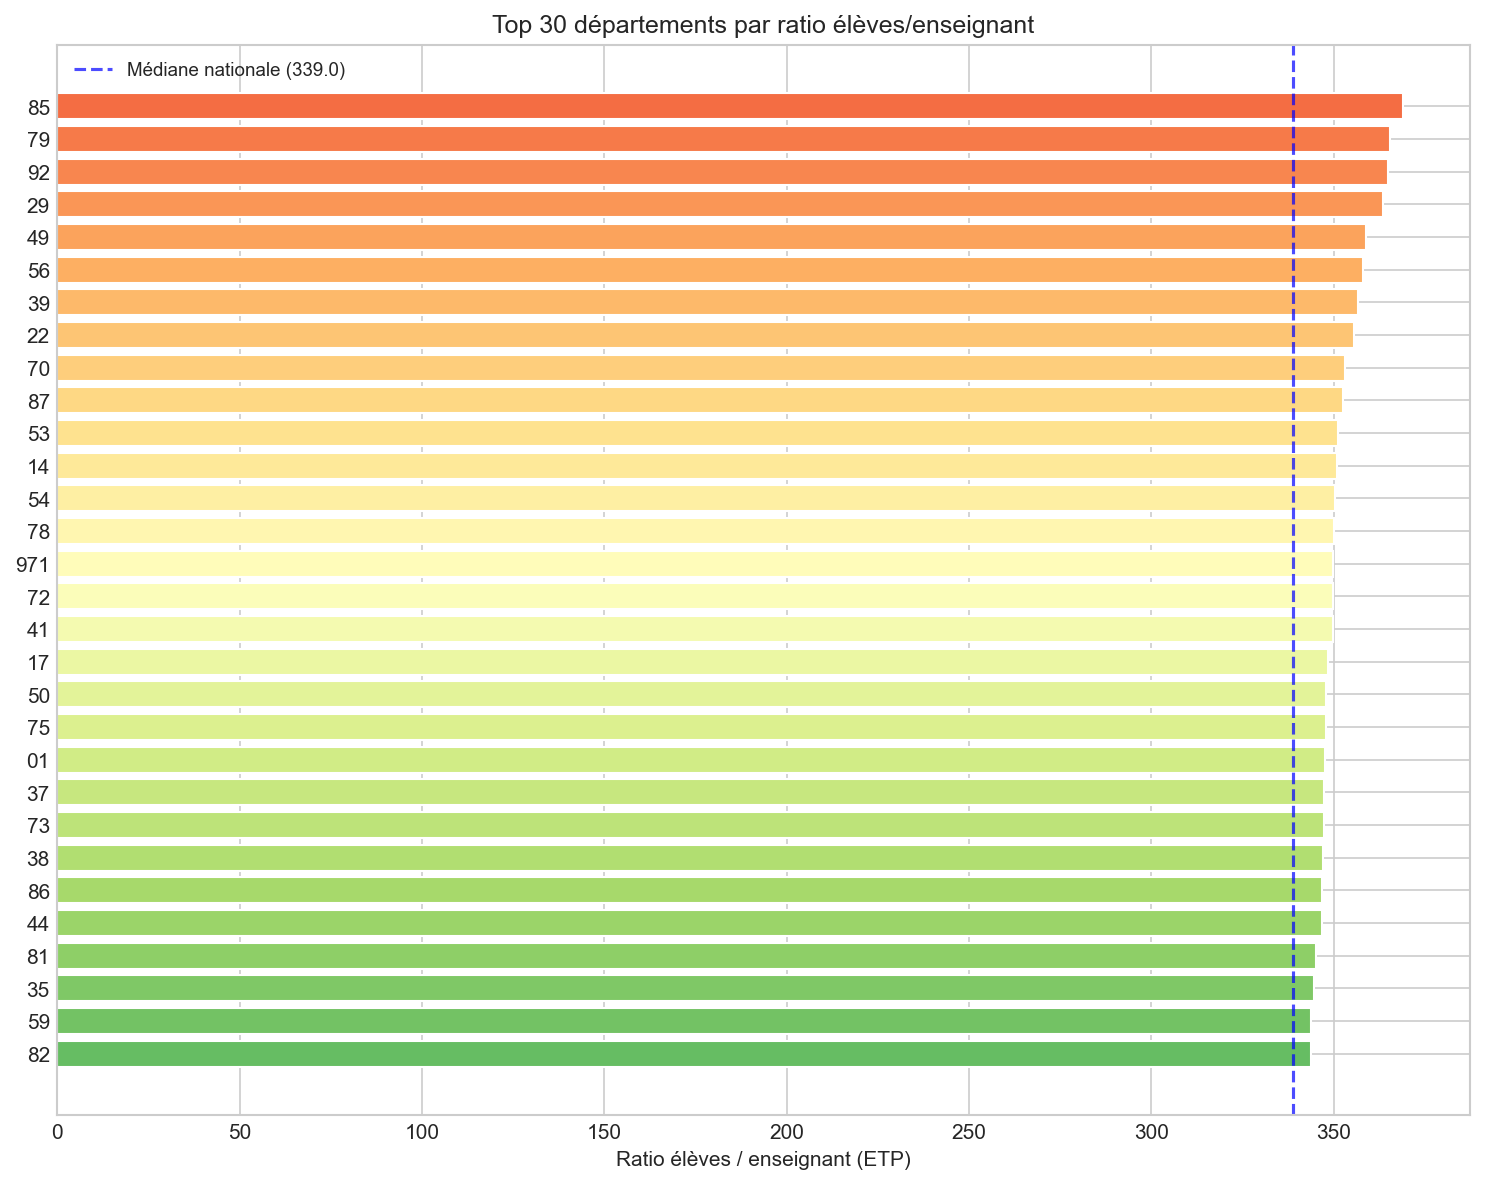

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
top_ratio = edu_dep.sort_values("ratio_eleves_enseignant", ascending=True).tail(30)

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_ratio)))
ax.barh(top_ratio["code_departement"], top_ratio["ratio_eleves_enseignant"], color=colors, edgecolor="white")
ax.axvline(x=edu_dep["ratio_eleves_enseignant"].median(), color="blue", linestyle="--", alpha=0.7,
           label=f"Médiane nationale ({edu_dep['ratio_eleves_enseignant'].median():.1f})")
ax.set_xlabel("Ratio élèves / enseignant (ETP)")
ax.set_title("Top 30 départements par ratio élèves/enseignant")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS / "07_ratio_eleves_enseignant.png", bbox_inches="tight")
plt.show()

## 4.3 Pourcentage d'écoles en éducation prioritaire par département

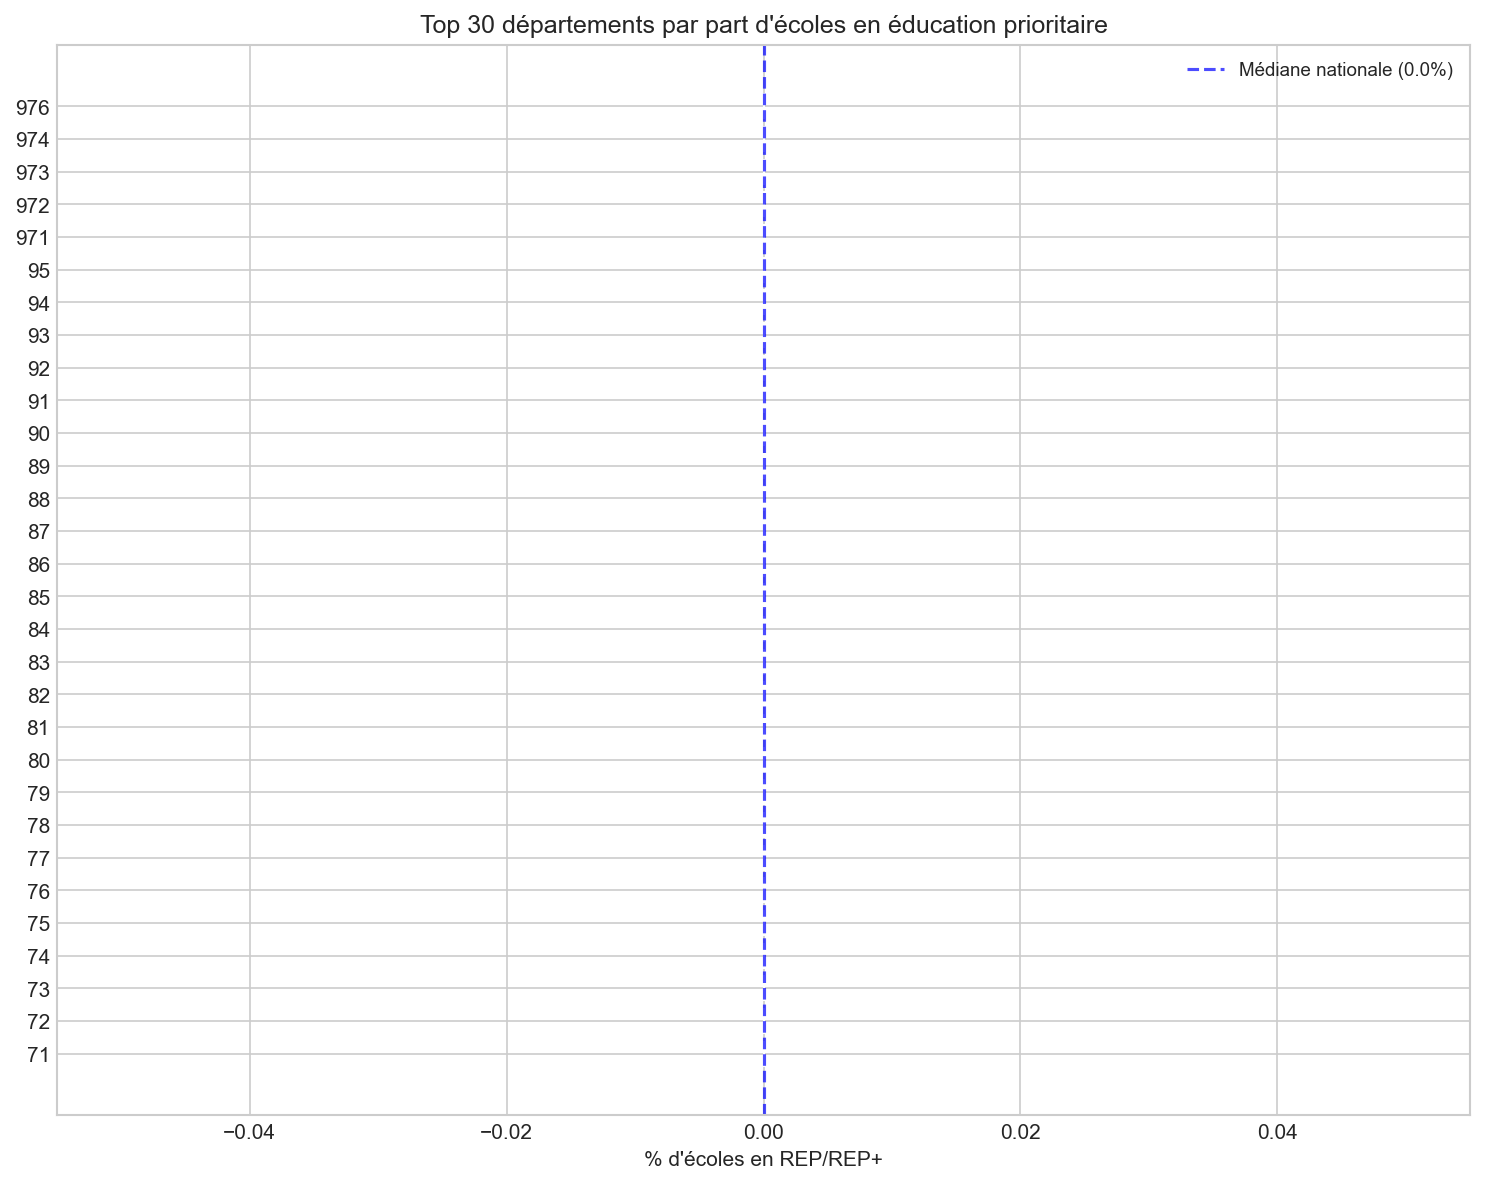

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
top_ep = edu_dep.sort_values("pct_ecoles_rep", ascending=True).tail(30)

colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top_ep)))
ax.barh(top_ep["code_departement"], top_ep["pct_ecoles_rep"], color=colors, edgecolor="white")
ax.axvline(x=edu_dep["pct_ecoles_rep"].median(), color="blue", linestyle="--", alpha=0.7,
           label=f"Médiane nationale ({edu_dep['pct_ecoles_rep'].median():.1f}%)")
ax.set_xlabel("% d'écoles en REP/REP+")
ax.set_title("Top 30 départements par part d'écoles en éducation prioritaire")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS / "08_education_prioritaire_departement.png", bbox_inches="tight")
plt.show()

## 4.4 Disparités REP/REP+ par académie

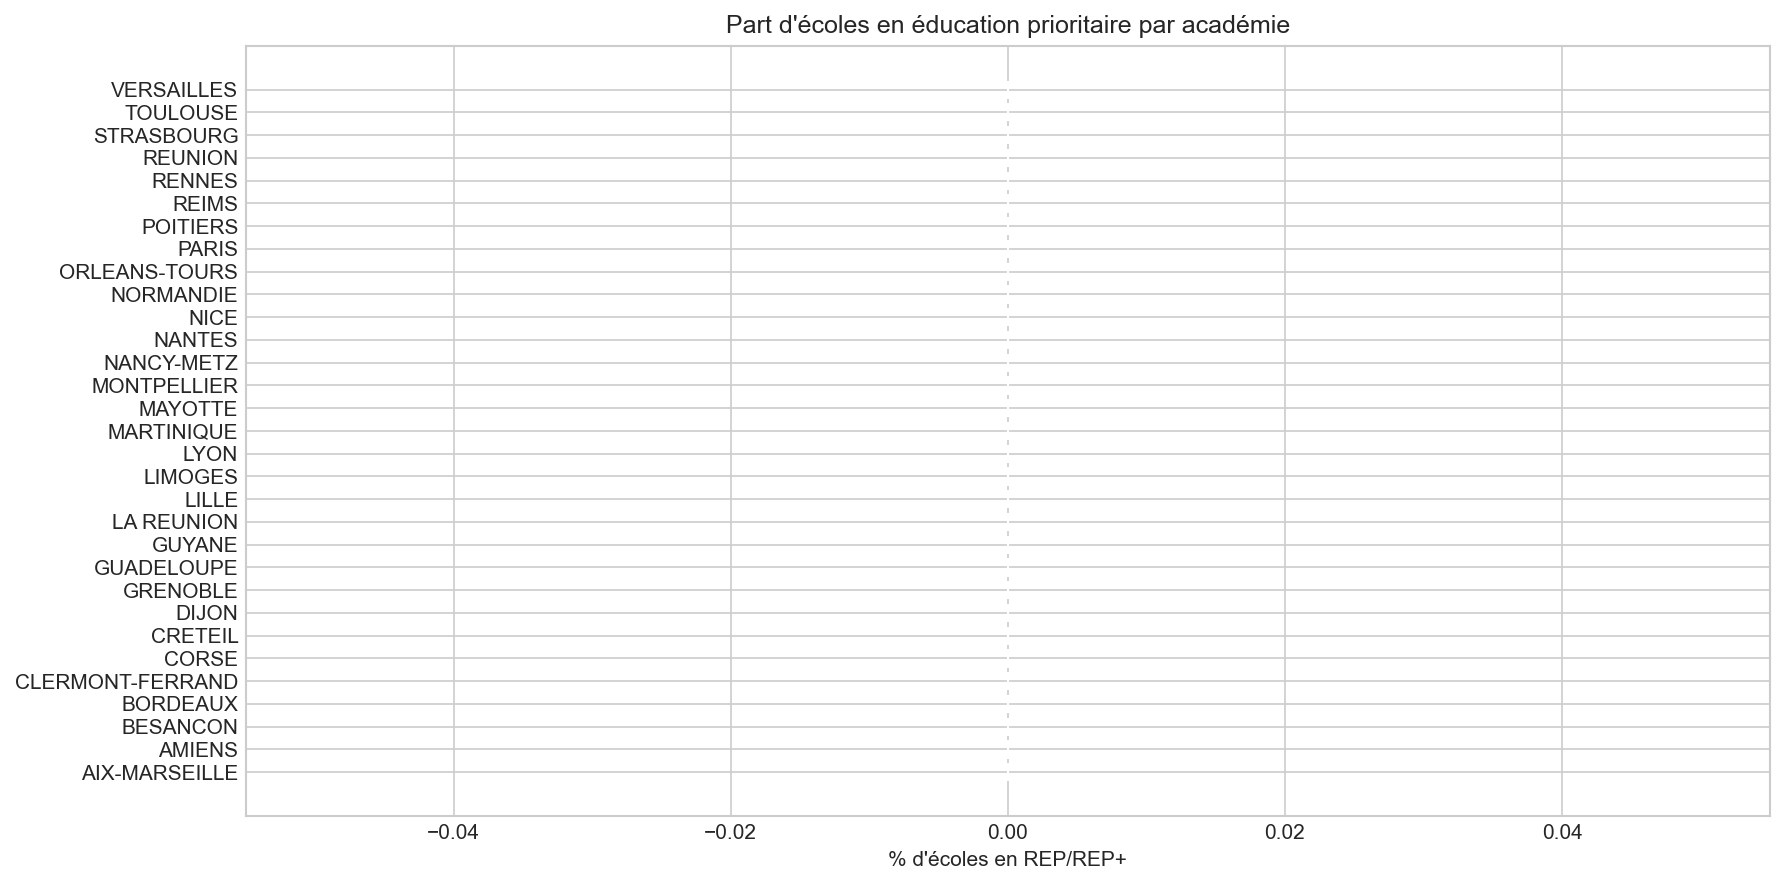

In [7]:
eleves_acad = eleves.groupby("Académie").agg(
    nb_ecoles=("uai", "nunique"),
    nb_eleves=("nb_eleves", "sum"),
    nb_rep=("REP", lambda x: (x == "REP").sum()),
    nb_repp=("REP+", lambda x: (x == "REP+").sum()),
).reset_index()
eleves_acad["pct_ep"] = (eleves_acad["nb_rep"] + eleves_acad["nb_repp"]) / eleves_acad["nb_ecoles"] * 100

fig, ax = plt.subplots(figsize=(12, 6))
acad_sorted = eleves_acad.sort_values("pct_ep", ascending=True)
colors = plt.cm.YlOrRd(np.linspace(0.2, 0.8, len(acad_sorted)))
ax.barh(acad_sorted["Académie"], acad_sorted["pct_ep"], color=colors, edgecolor="white")
ax.set_xlabel("% d'écoles en REP/REP+")
ax.set_title("Part d'écoles en éducation prioritaire par académie")
plt.tight_layout()
plt.savefig(OUTPUTS / "09_education_prioritaire_academie.png", bbox_inches="tight")
plt.show()

## Synthèse

In [8]:
print("=== SYNTHESE EDUCATION ===")
print(f"Total écoles           : {total_ecoles:,}")
print(f"Total élèves           : {total_eleves:,.0f}")
print(f"% en éducation prioritaire: {nb_epp/total_ecoles*100:.1f}%")
print(f"Ratio él/ens moyen       : {edu_dep['ratio_eleves_enseignant'].mean():.1f}")
print(f"Ratio él/ens médian      : {edu_dep['ratio_eleves_enseignant'].median():.1f}")
print(f"Dép. ratio le + élevé     : {top_ratio.iloc[-1]['code_departement']} ({top_ratio.iloc[-1]['ratio_eleves_enseignant']:.1f})")
print(f"Dép. ratio le + bas       : {edu_dep.sort_values('ratio_eleves_enseignant').iloc[0]['code_departement']} ({edu_dep.sort_values('ratio_eleves_enseignant').iloc[0]['ratio_eleves_enseignant']:.1f})")

=== SYNTHESE EDUCATION ===
Total écoles           : 809,225
Total élèves           : 105,988,320
% en éducation prioritaire: 0.0%
Ratio él/ens moyen       : 333.3
Ratio él/ens médian      : 339.0
Dép. ratio le + élevé     : 85 (369.0)
Dép. ratio le + bas       : 48 (240.8)
